# Regressão 01 - tarefa 03 - transformações em X e Y

Carregue os pacotes necessários e a base de gorjetas.

### I. Modelo no valor da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo em ```tip```, explicada por ```sex, smoker, diner e net_bill```.  
2. Remova as variáveis não significantes.  
3. observe o gráfico de resíduos em função de ```net_bill```  
4. teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.

In [102]:
import pandas as pd
import seaborn as sns
from seaborn import load_dataset
from patsy import dmatrices
import statsmodels.api as sm

import matplotlib.pyplot as plt

import numpy as np

import statsmodels.formula.api as smf

In [7]:
tips = sns.load_dataset("tips")
tips['tip_pct'] = tips['tip'] / (tips['total_bill'] - tips['tip'])
tips['net_bill'] = tips['total_bill'] - tips['tip']
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct,net_bill
0,16.99,1.01,Female,No,Sun,Dinner,2,0.063204,15.98
1,10.34,1.66,Male,No,Sun,Dinner,3,0.191244,8.68
2,21.01,3.50,Male,No,Sun,Dinner,3,0.199886,17.51
3,23.68,3.31,Male,No,Sun,Dinner,2,0.162494,20.37
4,24.59,3.61,Female,No,Sun,Dinner,4,0.172069,20.98


In [11]:
# Criar a matriz de design e a matriz de saída (y)
# 1. Criar a matriz de design e y
formula = 'tip ~ sex + smoker + time + net_bill'
y, X = dmatrices(formula, data=tips, return_type='dataframe')

In [19]:
# Ajustar o modelo inicial
modelo = sm.OLS(y, X).fit()
print(modelo.summary())

# 2. Refinar o modelo removendo variáveis não significantes
formula_refinada = 'tip ~ net_bill'
y_ref, X_ref = dmatrices(formula_refinada, data=tips, return_type='dataframe')
modelo_refinado = sm.OLS(y_ref, X_ref).fit()
print(modelo_refinado.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     30.13
Date:                Wed, 12 Mar 2025   Prob (F-statistic):           2.64e-20
Time:                        21:08:13   Log-Likelihood:                -375.13
No. Observations:                 244   AIC:                             760.3
Df Residuals:                     239   BIC:                             777.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.1999      0.242      4.

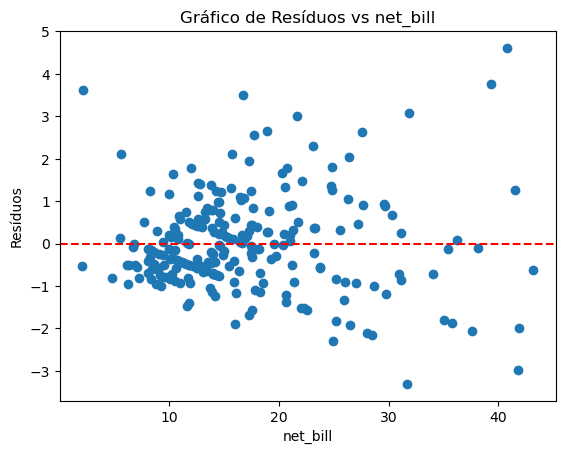

In [23]:
# 3. Gráfico de resíduos
residuos = modelo_refinado.resid
plt.scatter(tips['net_bill'], residuos)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('net_bill')
plt.ylabel('Resíduos')
plt.title('Gráfico de Resíduos vs net_bill')
plt.show()

In [32]:
# Adicionar transformação logarítmica
tips['log_net_bill'] = np.log(tips['net_bill'])

# Modelo com log
formula_log = 'tip ~ log_net_bill'
y_log, X_log = dmatrices(formula_log, data=tips[tips['net_bill'] > 0], return_type='dataframe')  # Removemos valores negativos
modelo_log = sm.OLS(y_log, X_log).fit()
print(modelo_log.summary())

# Adicionar transformação polinomial
tips['net_bill_squared'] = tips['net_bill'] ** 2

# Modelo com polinômio
formula_polinomio = 'tip ~ net_bill_squared'
y_poly, X_poly = dmatrices(formula_polinomio, data=tips, return_type='dataframe')
modelo_polinomio = sm.OLS(y_poly, X_poly).fit()
print(modelo_polinomio.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     101.0
Date:                Wed, 12 Mar 2025   Prob (F-statistic):           4.40e-20
Time:                        21:16:01   Log-Likelihood:                -382.40
No. Observations:                 244   AIC:                             768.8
Df Residuals:                     242   BIC:                             775.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.2575      0.430     -2.924   

In [34]:
print(f"AIC - Modelo Refinado: {modelo_refinado.aic}")
print(f"AIC - Modelo Log: {modelo_log.aic}")
print(f"AIC - Modelo Polinômio: {modelo_polinomio.aic}")

AIC - Modelo Refinado: 755.2579857451223
AIC - Modelo Log: 768.8028337874672
AIC - Modelo Polinômio: 766.6175774909121


O modelo com melhor ajuste conforme o R² foi o segundo modelo com a transformação polinomial, se considerarmos aqueles com transformações, mas dos três modelos, aquele sem transformações apresentou o melhor R² e o menor AIC, conforme o criterio, quanto menor melhor.

### II. Modelo no valor do percentual da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo no log de ```tip```, explicado por ```sex, smoker, diner e net_bill```.
2. Remova as variáveis não significantes.
3. Observe o gráfico de resíduos em função de ```net_bill```
4. Teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.
5. Do modelo final deste item, calcule o $R^2$ na escala de ```tip``` (sem o log). Compare com o modelo do item 1. Qual tem melhor coeficiente de determinação?

In [37]:
# Carregar os dados
tips = sns.load_dataset("tips")
tips['net_bill'] = tips['total_bill'] - tips['tip']
tips['log_tip'] = np.log(tips['tip'])  # Logaritmo de tip

# Criar a matriz de design
formula = 'log_tip ~ sex + smoker + time + net_bill'
y, X = dmatrices(formula, data=tips, return_type='dataframe')

# Ajustar o modelo inicial
modelo_inicial = sm.OLS(y, X).fit()
print(modelo_inicial.summary())

                            OLS Regression Results                            
Dep. Variable:                log_tip   R-squared:                       0.313
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     27.25
Date:                Wed, 12 Mar 2025   Prob (F-statistic):           1.21e-18
Time:                        21:24:17   Log-Likelihood:                -97.419
No. Observations:                 244   AIC:                             204.8
Df Residuals:                     239   BIC:                             222.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4504      0.078      5.

In [41]:
# Refinar o modelo
formula_refinada = 'log_tip ~ net_bill'
y_ref, X_ref = dmatrices(formula_refinada, data=tips, return_type='dataframe')

modelo_refinado = sm.OLS(y_ref, X_ref).fit()
print(modelo_refinado.summary())

                            OLS Regression Results                            
Dep. Variable:                log_tip   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     109.0
Date:                Wed, 12 Mar 2025   Prob (F-statistic):           2.60e-21
Time:                        21:34:07   Log-Likelihood:                -97.886
No. Observations:                 244   AIC:                             199.8
Df Residuals:                     242   BIC:                             206.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4945      0.054      9.172      0.0

Text(0.5, 1.0, 'Gráfico de Resíduos vs net_bill')

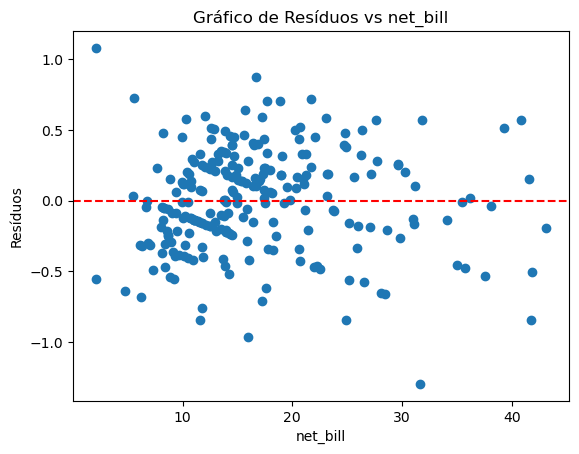

In [43]:
# Gráfico de resíduos
residuos = modelo_refinado.resid
plt.scatter(tips['net_bill'], residuos)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('net_bill')
plt.ylabel('Resíduos')
plt.title('Gráfico de Resíduos vs net_bill')

In [47]:
tips['log_net_bill'] = np.log(tips['net_bill'])

# Modelo com log de net_bill
formula_log = 'log_tip ~ log_net_bill'
y_log, X_log = dmatrices(formula_log, data=tips[tips['net_bill'] > 0], return_type='dataframe')
modelo_log = sm.OLS(y_log, X_log).fit()
print(modelo_log.summary())

                            OLS Regression Results                            
Dep. Variable:                log_tip   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     113.5
Date:                Wed, 12 Mar 2025   Prob (F-statistic):           5.62e-22
Time:                        21:35:32   Log-Likelihood:                -96.357
No. Observations:                 244   AIC:                             196.7
Df Residuals:                     242   BIC:                             203.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.3942      0.133     -2.961   

In [49]:
tips['net_bill_squared'] = tips['net_bill'] ** 2

# Modelo com termo polinomial
formula_polinomio = 'log_tip ~ net_bill_squared'
y_poly, X_poly = dmatrices(formula_polinomio, data=tips, return_type='dataframe')
modelo_polinomio = sm.OLS(y_poly, X_poly).fit()
print(modelo_polinomio.summary())

                            OLS Regression Results                            
Dep. Variable:                log_tip   R-squared:                       0.250
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     80.67
Date:                Wed, 12 Mar 2025   Prob (F-statistic):           7.70e-17
Time:                        21:35:48   Log-Likelihood:                -108.16
No. Observations:                 244   AIC:                             220.3
Df Residuals:                     242   BIC:                             227.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.7894      0.034  

In [51]:
# Comparar AIC
print(f"AIC - Modelo Refinado: {modelo_refinado.aic}")
print(f"AIC - Modelo Log: {modelo_log.aic}")
print(f"AIC - Modelo Polinômio: {modelo_polinomio.aic}")

AIC - Modelo Refinado: 199.77146767583906
AIC - Modelo Log: 196.71333547136817
AIC - Modelo Polinômio: 220.32440187142174


De acordo com o critério AIC e o R², o melhor modelo foi o modelo com Log.

### III. Previsão de renda

Vamos trabalhar a base que você vai usar no projeto do final deste ciclo.

Carregue a base ```previsao_de_renda.csv```.

|variavel|descrição|
|-|-|
|data_ref                | Data de referência de coleta das variáveis |
|index                   | Código de identificação do cliente|
|sexo                    | Sexo do cliente|
|posse_de_veiculo        | Indica se o cliente possui veículo|
|posse_de_imovel         | Indica se o cliente possui imóvel|
|qtd_filhos              | Quantidade de filhos do cliente|
|tipo_renda              | Tipo de renda do cliente|
|educacao                | Grau de instrução do cliente|
|estado_civil            | Estado civil do cliente|
|tipo_residencia         | Tipo de residência do cliente (própria, alugada etc)|
|idade                   | Idade do cliente|
|tempo_emprego           | Tempo no emprego atual|
|qt_pessoas_residencia   | Quantidade de pessoas que moram na residência|
|renda                   | Renda em reais|

1. Ajuste um modelo de regressão linear simples para explicar ```renda``` como variável resposta, por ```tempo_emprego``` como variável explicativa. Observe que há muitas observações nessa tabela. Utilize os recursos que achar necessário.
2. Faça uma análise de resíduos. Com os recursos vistos neste módulo, como você melhoraria esta regressão?
3. Ajuste um modelo de regressão linear múltipla para explicar ```renda``` (ou uma transformação de ```renda```) de acordo com as demais variáveis.
4. Remova as variáveis não significantes e ajuste novamente o modelo. Interprete os parâmetros
5. Faça uma análise de resíduos. Avalie a qualidade do ajuste.

In [106]:

# Carregar a base de dados
dados = pd.read_csv("previsao_de_renda.csv")


# Exibir as primeiras linhas para verificar os dados
print(dados.head())

   Unnamed: 0    data_ref  id_cliente sexo  posse_de_veiculo  posse_de_imovel  \
0           0  2015-01-01       15056    F             False             True   
1           1  2015-01-01        9968    M              True             True   
2           2  2015-01-01        4312    F              True             True   
3           3  2015-01-01       10639    F             False             True   
4           4  2015-01-01        7064    M              True            False   

   qtd_filhos        tipo_renda           educacao estado_civil  \
0           0        Empresário         Secundário     Solteiro   
1           0       Assalariado  Superior completo       Casado   
2           0        Empresário  Superior completo       Casado   
3           1  Servidor público  Superior completo       Casado   
4           0       Assalariado         Secundário     Solteiro   

  tipo_residencia  idade  tempo_emprego  qt_pessoas_residencia    renda  
0            Casa     26       6.602

tempo_emprego    2573
renda               0
dtype: int64
tempo_emprego    0
renda            0
dtype: int64
                            OLS Regression Results                            
Dep. Variable:                  renda   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     2162.
Date:                Wed, 12 Mar 2025   Prob (F-statistic):               0.00
Time:                        23:22:11   Log-Likelihood:            -1.2963e+05
No. Observations:               12427   AIC:                         2.593e+05
Df Residuals:                   12425   BIC:                         2.593e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------

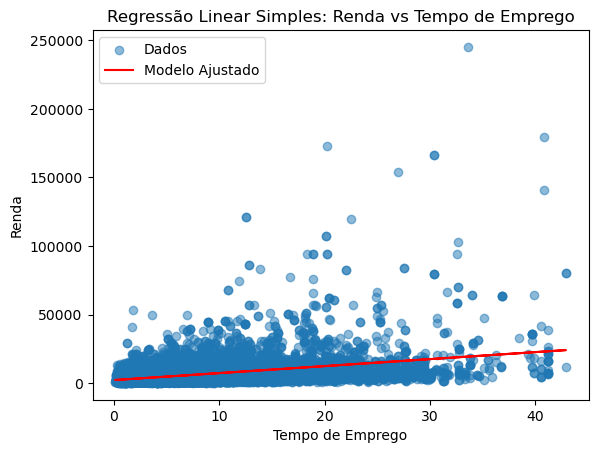

In [108]:
# Verificar se há valores ausentes ou infinitos
print(dados[['tempo_emprego', 'renda']].isna().sum())  # Valores nulos
print(np.isinf(dados[['tempo_emprego', 'renda']]).sum())  # Valores infinitos

# Remover linhas com valores ausentes ou infinitos
dados_limpos = dados.replace([np.inf, -np.inf], np.nan).dropna(subset=['tempo_emprego', 'renda'])

# Ajustar o modelo novamente com os dados limpos
X = dados_limpos[['tempo_emprego']]
y = dados_limpos['renda']

# Adicionar constante
X = sm.add_constant(X)

# Ajustar o modelo
modelo = sm.OLS(y, X).fit()

# Resumo do modelo
print(modelo.summary())

# Gráfico de dispersão com linha de regressão
plt.scatter(dados_limpos['tempo_emprego'], dados_limpos['renda'], alpha=0.5, label='Dados')
plt.plot(dados_limpos['tempo_emprego'], modelo.predict(X), color='red', label='Modelo Ajustado')
plt.xlabel('Tempo de Emprego')
plt.ylabel('Renda')
plt.legend()
plt.title('Regressão Linear Simples: Renda vs Tempo de Emprego')
plt.show()

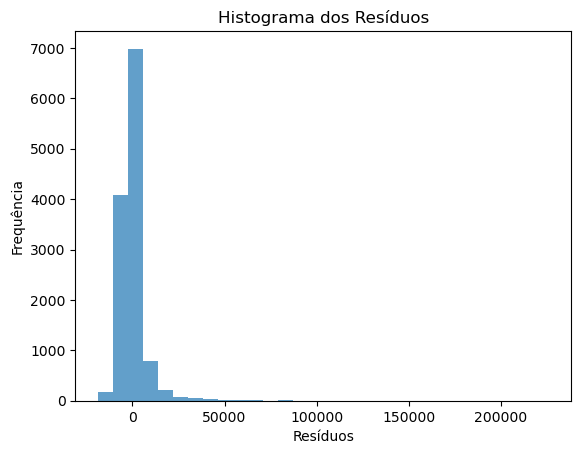

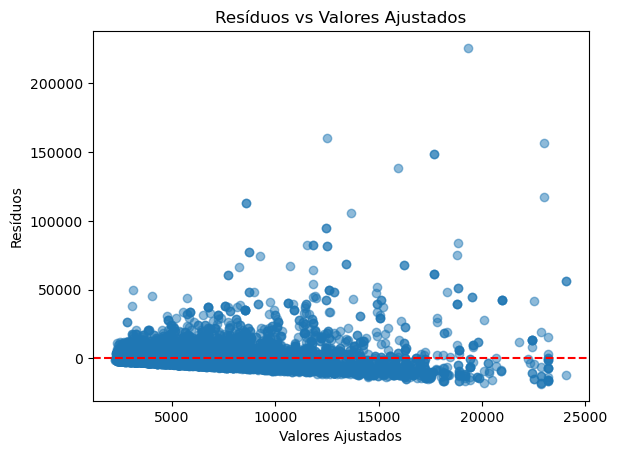

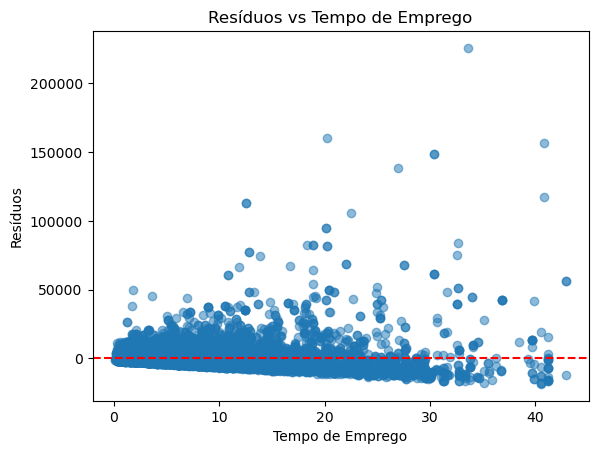

In [110]:
# Resíduos do modelo ajustado
residuos = modelo.resid

# 1. Histograma dos resíduos
plt.hist(residuos, bins=30, alpha=0.7)
plt.title('Histograma dos Resíduos')
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.show()

# 2. Resíduos vs valores ajustados (verificar padrões)
valores_ajustados = modelo.fittedvalues
plt.scatter(valores_ajustados, residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')
plt.title('Resíduos vs Valores Ajustados')
plt.show()

# 3. Resíduos vs variável explicativa (tempo_emprego)
plt.scatter(dados_limpos['tempo_emprego'], residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Tempo de Emprego')
plt.ylabel('Resíduos')
plt.title('Resíduos vs Tempo de Emprego')
plt.show()


Poderia experimentar transformar a variável x ou y, para log por exemplo ou polinomial.

In [112]:
# Verificar e limpar os dados
dados = dados.replace([np.inf, -np.inf], np.nan).dropna()
print(dados.info())  

<class 'pandas.core.frame.DataFrame'>
Index: 12427 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             12427 non-null  int64  
 1   data_ref               12427 non-null  object 
 2   id_cliente             12427 non-null  int64  
 3   sexo                   12427 non-null  object 
 4   posse_de_veiculo       12427 non-null  bool   
 5   posse_de_imovel        12427 non-null  bool   
 6   qtd_filhos             12427 non-null  int64  
 7   tipo_renda             12427 non-null  object 
 8   educacao               12427 non-null  object 
 9   estado_civil           12427 non-null  object 
 10  tipo_residencia        12427 non-null  object 
 11  idade                  12427 non-null  int64  
 12  tempo_emprego          12427 non-null  float64
 13  qt_pessoas_residencia  12427 non-null  float64
 14  renda                  12427 non-null  float64
dtypes: bool

In [122]:
# Especificar o modelo de regressão linear múltipla
modelo = smf.ols('renda ~ sexo + posse_de_veiculo + posse_de_imovel + qtd_filhos + tipo_renda' 
                 '+ educacao + estado_civil + tipo_residencia + idade + tempo_emprego + qt_pessoas_residencia', data=dados).fit()

# Resumo do modelo
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                  renda   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     178.0
Date:                Wed, 12 Mar 2025   Prob (F-statistic):               0.00
Time:                        23:30:29   Log-Likelihood:            -1.2879e+05
No. Observations:               12427   AIC:                         2.576e+05
Df Residuals:                   12402   BIC:                         2.578e+05
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [128]:
# Especificar o modelo de regressão linear múltipla - Refinar
modelo = smf.ols('renda ~ sexo + posse_de_imovel + tipo_renda' 
                 ' + estado_civil + idade + tempo_emprego', data=dados).fit()

# Resumo do modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  renda   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     353.3
Date:                Wed, 12 Mar 2025   Prob (F-statistic):               0.00
Time:                        23:33:19   Log-Likelihood:            -1.2880e+05
No. Observations:               12427   AIC:                         2.576e+05
Df Residuals:                   12414   BIC:                         2.577e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

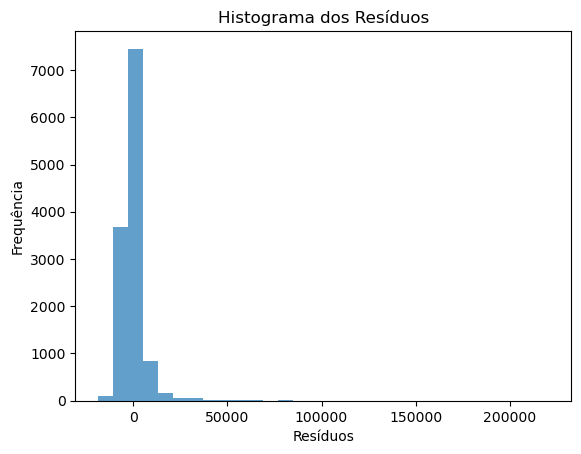

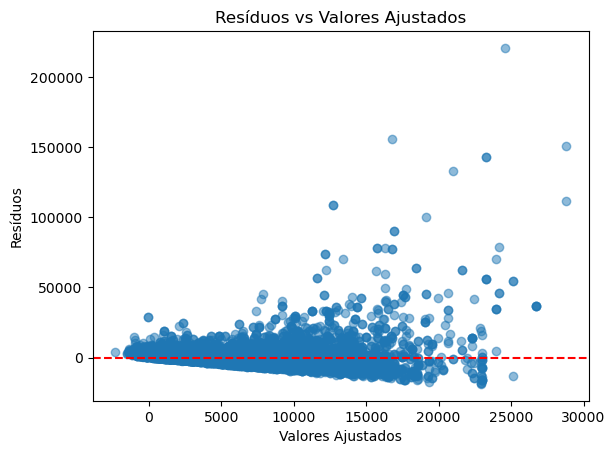

In [130]:
# Resíduos do modelo
residuos = modelo.resid

# Histograma dos resíduos
plt.hist(residuos, bins=30, alpha=0.7)
plt.title('Histograma dos Resíduos')
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.show()

# Resíduos vs valores ajustados
valores_ajustados = modelo.fittedvalues
plt.scatter(valores_ajustados, residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')
plt.title('Resíduos vs Valores Ajustados')
plt.show()


O R² talvez pudesse ficar melhor com a transformação da variável dependente, mas dado que estamos falando de comportamentos, em muitos cenários os resíduos podem não apresentarem o melhor ajuste.